# **Langkah 1**: Download dan Baca Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/dibimbing.id DABI 20 - Addo Abiesa/Exam Penyaluran Kerja/Dataset Trip Pricing with Taxi Mobility Analytics_Möbius/sigma_cabs.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131662 entries, 0 to 131661
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Trip_ID                      131662 non-null  object 
 1   Trip_Distance                131662 non-null  float64
 2   Type_of_Cab                  111452 non-null  object 
 3   Customer_Since_Months        125742 non-null  float64
 4   Life_Style_Index             111469 non-null  float64
 5   Confidence_Life_Style_Index  111469 non-null  object 
 6   Destination_Type             131662 non-null  object 
 7   Customer_Rating              131662 non-null  float64
 8   Cancellation_Last_1Month     131662 non-null  int64  
 9   Var1                         60632 non-null   float64
 10  Var2                         131662 non-null  int64  
 11  Var3                         131662 non-null  int64  
 12  Gender                       131662 non-null  object 
 13 

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type
count,131662.000000,125742.000000,111469.000000,131662.000000,131662.000000,60632.000000,131662.000000,131662.000000,131662.000000
mean,44.200909,6.016661,2.802064,2.849458,0.782838,64.202698,51.202800,75.099019,2.155747
std,25.522882,3.626887,0.225796,0.980675,1.037559,21.820447,4.986142,11.578278,0.738164
min,0.310000,0.000000,1.596380,0.001250,0.000000,30.000000,40.000000,52.000000,1.000000
25%,24.580000,3.000000,2.654730,2.152500,0.000000,46.000000,48.000000,67.000000,2.000000
50%,38.200000,6.000000,2.798050,2.895000,0.000000,61.000000,50.000000,74.000000,2.000000
75%,60.730000,10.000000,2.946780,3.582500,1.000000,80.000000,54.000000,82.000000,3.000000
max,109.230000,10.000000,4.875110,5.000000,8.000000,210.000000,124.000000,206.000000,3.000000


# **Langkah 2**: Data Cleaning

**1. Cek _missing values_**

In [25]:
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print("\nMissing values awal:")
print(df.isnull().sum())

Jumlah baris: 131662
Jumlah kolom: 14

Missing values awal:
Trip_ID                            0
Trip_Distance                      0
Type_of_Cab                    20210
Customer_Since_Months           5920
Life_Style_Index               20193
Confidence_Life_Style_Index    20193
Destination_Type                   0
Customer_Rating                    0
Cancellation_Last_1Month           0
Var1                           71030
Var2                               0
Var3                               0
Gender                             0
Surge_Pricing_Type                 0
dtype: int64


**2. _Handle missing values_**

2.1. Kolom Kategorikal: Modus

In [26]:
#Type_of_Cab
mode_cab = df['Type_of_Cab'].mode()[0]
df['Type_of_Cab'] = df['Type_of_Cab'].fillna(mode_cab)
print(f"TYpe_of_Cab diisi dengan: {mode_cab}")

TYpe_of_Cab diisi dengan: B


In [27]:
#Confidence_Life_Style_Index
mode_confidence = df['Confidence_Life_Style_Index'].mode()[0]
df['Confidence_Life_Style_Index'] = df['Confidence_Life_Style_Index'].fillna(mode_confidence)
print(f"Confidence_Life_Style_Index diisi dengan: {mode_confidence}")

Confidence_Life_Style_Index diisi dengan: B


2.2. Kolom Numerik: Median

In [28]:
#Customer_Since_Months
median_customer = df['Customer_Since_Months'].median()
df['Customer_Since_Months'] = df['Customer_Since_Months'].fillna(median_customer)
print(f"Customer_Since_Months diisi dengan: {median_customer}")

Customer_Since_Months diisi dengan: 6.0


In [29]:
#Customer_Since_Months
median_lifestyle = df['Life_Style_Index'].median()
df['Life_Style_Index'] = df['Life_Style_Index'].fillna(median_lifestyle)
print(f"Life_Style_Index diisi dengan: {median_lifestyle}")

Life_Style_Index diisi dengan: 2.79805


In [30]:
#Var1
median_var1 = df['Var1'].median()
df['Var1'] = df['Var1'].fillna(median_var1)
print(f"Var1 diisi dengan: {median_var1}")

Var1 diisi dengan: 61.0


In [31]:
#Cek ulang missing values
print("\nMissing values akhir:")
print(df.isnull().sum())


Missing values akhir:
Trip_ID                        0
Trip_Distance                  0
Type_of_Cab                    0
Customer_Since_Months          0
Life_Style_Index               0
Confidence_Life_Style_Index    0
Destination_Type               0
Customer_Rating                0
Cancellation_Last_1Month       0
Var1                           0
Var2                           0
Var3                           0
Gender                         0
Surge_Pricing_Type             0
dtype: int64


**3. Cek duplikat dan _outlier_**

3.1. Cek duplikat

In [32]:
duplicates = df.duplicated().sum()
print(f"Jumlah duplikat: {duplicates}")

Jumlah duplikat: 0


3.2. Cek Outlier

*   Customer_Rating

In [33]:
rating_min = df['Customer_Rating'].min()
rating_max = df['Customer_Rating'].max()
print(f"Rating terkecil: {rating_min}")
print(f"Rating terbesar: {rating_max}")

Rating terkecil: 0.00125
Rating terbesar: 5.0


In [34]:
outlier_rating = df[df['Customer_Rating'] < 0.1]
print(f"\nJumlah data dengan rating < 0.1: {len(outlier_rating)}")


Jumlah data dengan rating < 0.1: 140


In [35]:
if len(outlier_rating) > 0:
    print("\nContoh data rating aneh (5 baris pertama):")
    print(outlier_rating[['Trip_ID', 'Customer_Rating']].head())

    # Hapus data dengan rating < 0.1
    df = df[df['Customer_Rating'] >= 0.1]
    print(f"\nData dengan rating < 0.1 telah dihapus.")
    print(f"Jumlah baris setelah drop outlier rating: {len(df)}")
else:
    print("\nTidak ada outlier pada Customer_Rating.")


Contoh data rating aneh (5 baris pertama):
          Trip_ID  Customer_Rating
210   T0005689813          0.00250
939   T0005691000          0.01625
1101  T0005691263          0.02875
1506  T0005691923          0.02500
2239  T0005693121          0.02625

Data dengan rating < 0.1 telah dihapus.
Jumlah baris setelah drop outlier rating: 131522


*   Cancellation_Last_1Month

In [ ]:
cancel_max = df['Cancellation_Last_1Month'].max()
cancel_min = df['Cancellation_Last_1Month'].min()
print(f"Cancellation_Last_1Month terkecil: {cancel_min}")
print(f"Cancellation_Last_1Month terbesar: {cancel_max}")

Cancellation_Last_1Month terkecil: 0
Cancellation_Last_1Month terbesar: 8


In [36]:
outlier_cancel = df[df['Cancellation_Last_1Month'] > 1]
print(f"Jumlah outlier Cancellation_Last_1Month > 1: {len(outlier_cancel)}")

Jumlah outlier Cancellation_Last_1Month > 1: 26124


In [37]:
if len(outlier_cancel) > 0:
    print("\nContoh data cancellation tinggi (5 baris pertama):")
    print(outlier_cancel[['Trip_ID', 'Cancellation_Last_1Month']].head())
    print("\nCatatan: Data cancellation > 5 tidak di-drop dulu.")
    print("Akan ditinjau di EDA apakah berpengaruh signifikan.")
else:
    print("\nTidak ada outlier pada Cancellation.")


Contoh data cancellation tinggi (5 baris pertama):
        Trip_ID  Cancellation_Last_1Month
2   T0005689464                         2
4   T0005689467                         4
10  T0005689475                         2
12  T0005689479                         2
19  T0005689492                         5

Catatan: Data cancellation > 5 tidak di-drop dulu.
Akan ditinjau di EDA apakah berpengaruh signifikan.


*   Trip_Distance

In [ ]:
distance_max = df['Trip_Distance'].max()
distance_min = df['Trip_Distance'].min()
print(f"Trip_Distance terkecil: {distance_min}")
print(f"Trip_Distance terbesar: {distance_max}")

Trip_Distance terkecil: 0.31
Trip_Distance terbesar: 109.23


# **Langkah 3**: _Feature Engineering_

3.1. Kategori jarak perjalanan

In [39]:
def distance_category(distance):
    if distance < 25:
        return 'Short (<25 km)'
    elif distance <= 60:
        return 'Medium (25-60 km)'
    else:
        return 'Long (>60 km)'

df['Distance_Category'] = df['Trip_Distance'].apply(distance_category)
df.head()

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type,Distance_Category
0,T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2,Short (<25 km)
1,T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2,Medium (25-60 km)
2,T0005689464,41.58,B,10.0,2.79805,B,E,3.50125,2,61.0,56,77,Male,2,Medium (25-60 km)
3,T0005689465,61.56,C,10.0,2.79805,B,A,3.45375,0,61.0,52,74,Male,3,Long (>60 km)
4,T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2,Medium (25-60 km)


3.2. Kategori loyalitas plelanggan (berdasarkan Customer_Since_Months)

In [40]:
def loyalty_category(months):
    if months <= 3:
        return 'New (0-3 Mo)'
    elif months <= 7:
        return 'Regular (4-7 Mo)'
    else:
        return 'Loyal (>7 Mo)'

df['Loyalty_Category'] = df['Customer_Since_Months'].apply(loyalty_category)
df.head()

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type,Distance_Category,Loyalty_Category
0,T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2,Short (<25 km),New (0-3 Mo)
1,T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2,Medium (25-60 km),Loyal (>7 Mo)
2,T0005689464,41.58,B,10.0,2.79805,B,E,3.50125,2,61.0,56,77,Male,2,Medium (25-60 km),Loyal (>7 Mo)
3,T0005689465,61.56,C,10.0,2.79805,B,A,3.45375,0,61.0,52,74,Male,3,Long (>60 km),Loyal (>7 Mo)
4,T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2,Medium (25-60 km),Loyal (>7 Mo)


3.3. Kategori rating perjalanan

In [45]:
def rating_category(rating):
    if rating < 2:
        return 'Low (< 2)'
    elif rating < 4:
        return 'Medium (2-4)'
    else:
        return 'High (>4)'

df['Rating_Category'] = df['Customer_Rating'].apply(rating_category)
df.head()

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type,Distance_Category,Loyalty_Category,Cancellation_Category,Rating_Category
0,T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2,Short (<25 km),New (0-3 Mo),No Cancellation,Medium (2-4)
1,T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2,Medium (25-60 km),Loyal (>7 Mo),No Cancellation,Medium (2-4)
2,T0005689464,41.58,B,10.0,2.79805,B,E,3.50125,2,61.0,56,77,Male,2,Medium (25-60 km),Loyal (>7 Mo),Cancellation,Medium (2-4)
3,T0005689465,61.56,C,10.0,2.79805,B,A,3.45375,0,61.0,52,74,Male,3,Long (>60 km),Loyal (>7 Mo),No Cancellation,Medium (2-4)
4,T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2,Medium (25-60 km),Loyal (>7 Mo),Cancellation,Medium (2-4)


3.4. Kategori Cancellation

In [46]:
def cancellation_category(cancellation):
    if cancellation == 0:
        return 'None (0)'
    elif cancellation <=2:
        return 'Low (1-2)'
    else:
        return 'High (>2)'

df['Cancellation_Category'] = df['Cancellation_Last_1Month'].apply(cancellation_category)
df.head()

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type,Distance_Category,Loyalty_Category,Cancellation_Category,Rating_Category
0,T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2,Short (<25 km),New (0-3 Mo),None (0),Medium (2-4)
1,T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2,Medium (25-60 km),Loyal (>7 Mo),None (0),Medium (2-4)
2,T0005689464,41.58,B,10.0,2.79805,B,E,3.50125,2,61.0,56,77,Male,2,Medium (25-60 km),Loyal (>7 Mo),Low (1-2),Medium (2-4)
3,T0005689465,61.56,C,10.0,2.79805,B,A,3.45375,0,61.0,52,74,Male,3,Long (>60 km),Loyal (>7 Mo),None (0),Medium (2-4)
4,T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2,Medium (25-60 km),Loyal (>7 Mo),High (>2),Medium (2-4)


**PERIKSA HASIL**

In [48]:
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print("\nKolom baru:")
print(df[['Distance_Category', 'Loyalty_Category', 'Rating_Category', 'Cancellation_Category']].head())

Jumlah baris: 131522
Jumlah kolom: 18

Kolom baru:
   Distance_Category Loyalty_Category Rating_Category Cancellation_Category
0     Short (<25 km)     New (0-3 Mo)    Medium (2-4)              None (0)
1  Medium (25-60 km)    Loyal (>7 Mo)    Medium (2-4)              None (0)
2  Medium (25-60 km)    Loyal (>7 Mo)    Medium (2-4)             Low (1-2)
3      Long (>60 km)    Loyal (>7 Mo)    Medium (2-4)              None (0)
4  Medium (25-60 km)    Loyal (>7 Mo)    Medium (2-4)             High (>2)


**DISTRIBUSI KOLOM BARU**

In [50]:
print("\nDistance_Category:")
print(df['Distance_Category'].value_counts())

print("\nLoyalty_Category:")
print(df['Loyalty_Category'].value_counts())

print("\nRating_Category:")
print(df['Rating_Category'].value_counts())

print("\nCancellation_Category:")
print(df['Cancellation_Category'].value_counts())


Distance_Category:
Distance_Category
Medium (25-60 km)    62801
Long (>60 km)        34874
Short (<25 km)       33847
Name: count, dtype: int64

Loyalty_Category:
Loyalty_Category
Loyal (>7 Mo)       54096
New (0-3 Mo)        40399
Regular (4-7 Mo)    37027
Name: count, dtype: int64

Rating_Category:
Rating_Category
Medium (2-4)    87589
Low (< 2)       27011
High (>4)       16922
Name: count, dtype: int64

Cancellation_Category:
Cancellation_Category
None (0)     68598
Low (1-2)    53010
High (>2)     9914
Name: count, dtype: int64


# **Langkah 4**: _EDA & Insight_

4.1. Distribusi `Surge_Pricing_Type`

In [54]:
print(df['Surge_Pricing_Type'].value_counts())
print(df['Surge_Pricing_Type'].value_counts(normalize=True)*100)

Surge_Pricing_Type
2    56677
3    47637
1    27208
Name: count, dtype: int64
Surge_Pricing_Type
2    43.093171
3    36.219796
1    20.687033
Name: proportion, dtype: float64


/tmp/ipykernel_983/2373634314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Surge_Pricing_Type', palette='viridis')


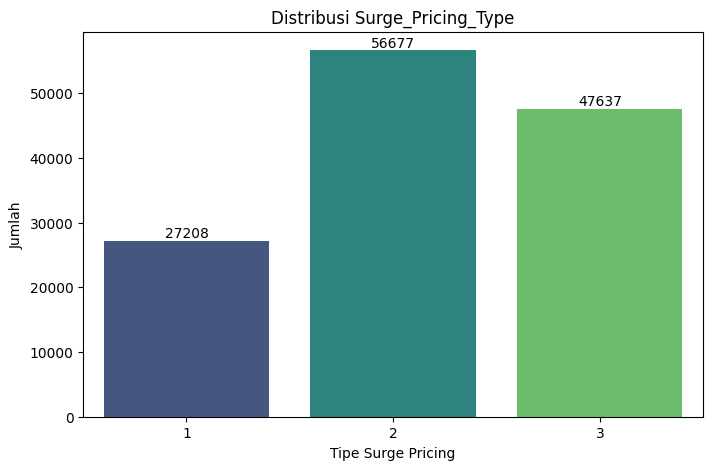

In [56]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Surge_Pricing_Type', palette='viridis')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Jumlah')
plt.title('Distribusi Surge_Pricing_Type')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

4.2. Pengaruh jarak terhadap _surge pricing_

In [58]:
print(df.groupby('Surge_Pricing_Type')['Trip_Distance'].describe())

                      count       mean        std   min      25%     50%  \
Surge_Pricing_Type                                                         
1                   27208.0  41.061724  22.437695  0.31  23.5575  36.685   
2                   56677.0  41.271976  23.896768  1.59  23.3800  36.170   
3                   47637.0  49.483154  28.073038  1.54  28.3100  45.530   

                      75%     max  
Surge_Pricing_Type                 
1                   56.10  109.22  
2                   55.34  109.23  
3                   67.88  109.23  


/tmp/ipykernel_983/405791736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Surge_Pricing_Type', y='Trip_Distance', palette='viridis')


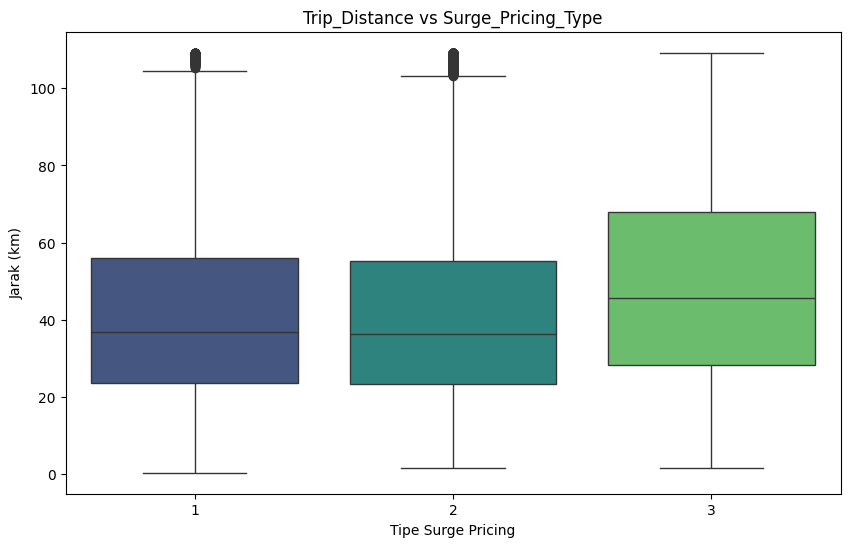

In [59]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Surge_Pricing_Type', y='Trip_Distance', palette='viridis')
plt.title('Trip_Distance vs Surge_Pricing_Type')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Jarak (km)')
plt.show()

4.3. Pengaruh _rating_ pelanggan terhadap _surge pricing_

In [60]:
print(df.groupby('Surge_Pricing_Type')['Customer_Rating'].describe())

                      count      mean       std     min    25%      50%  \
Surge_Pricing_Type                                                        
1                   27208.0  3.113467  0.914207  0.1025  2.475  3.17125   
2                   56677.0  2.860209  0.965987  0.1000  2.175  2.90625   
3                   47637.0  2.694091  0.991717  0.1000  1.985  2.71375   

                        75%  max  
Surge_Pricing_Type                
1                   3.80000  5.0  
2                   3.58000  5.0  
3                   3.42625  5.0  


/tmp/ipykernel_983/101102970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Surge_Pricing_Type', y='Customer_Rating', palette='viridis')


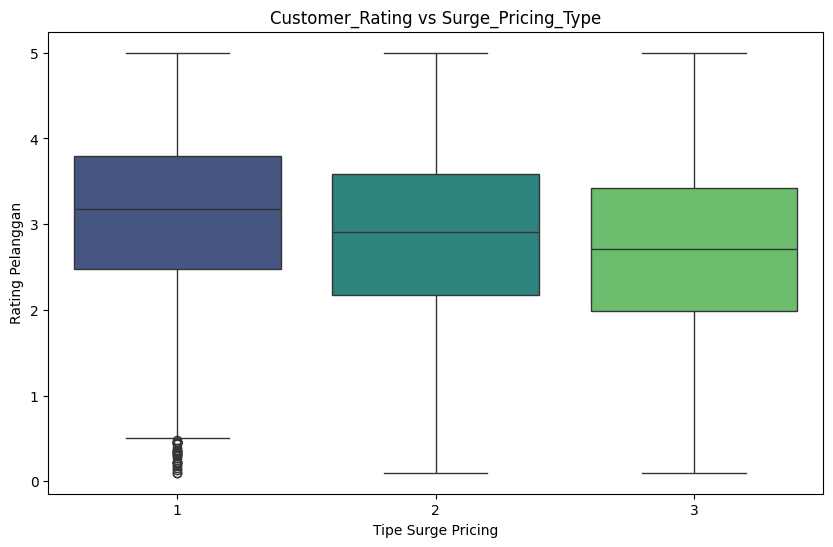

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Surge_Pricing_Type', y='Customer_Rating', palette='viridis')
plt.title('Customer_Rating vs Surge_Pricing_Type')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Rating Pelanggan')
plt.show()

4.4. Pengaruh _cancellation_ terhadap _surge pricing_

In [62]:
print(pd.crosstab(df['Cancellation_Category'], df['Surge_Pricing_Type']))

Surge_Pricing_Type         1      2      3
Cancellation_Category                     
High (>2)               1048   3544   5322
Low (1-2)               8490  21739  22781
None (0)               17670  31394  19534


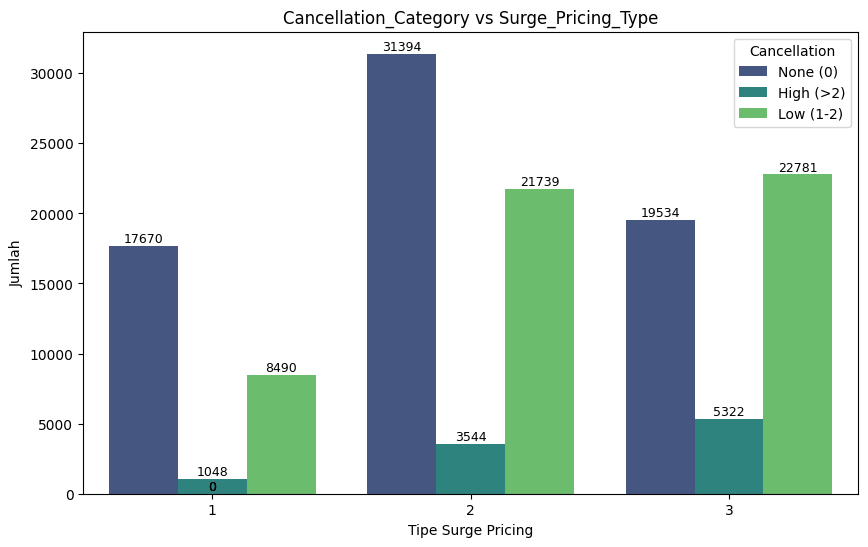

In [65]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='Surge_Pricing_Type', hue='Cancellation_Category', palette='viridis')
plt.title('Cancellation_Category vs Surge_Pricing_Type')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Jumlah')
plt.legend(title='Cancellation')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

4.5. Pengaruh loyalitas pelanggan terhadap _surge pricing_

In [67]:
print(pd.crosstab(df['Loyalty_Category'], df['Surge_Pricing_Type']))

Surge_Pricing_Type      1      2      3
Loyalty_Category                       
Loyal (>7 Mo)       10882  23005  20209
New (0-3 Mo)         8744  17777  13878
Regular (4-7 Mo)     7582  15895  13550


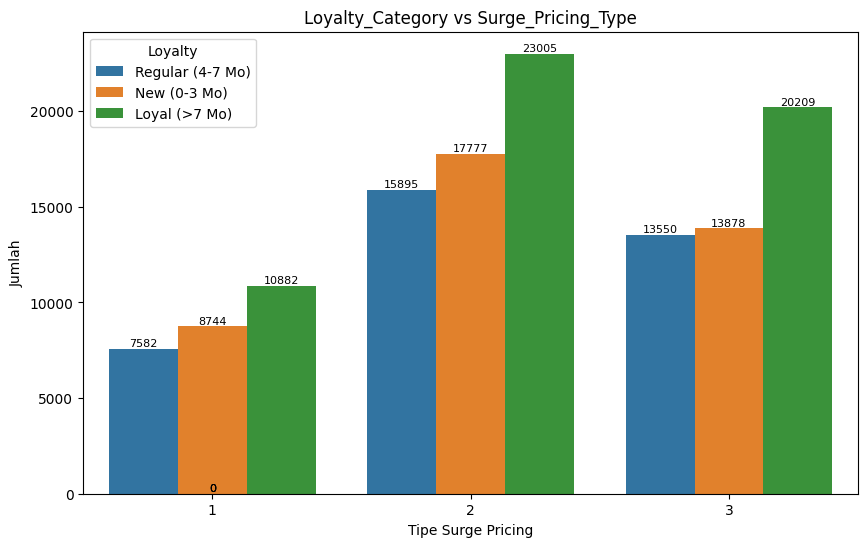

In [68]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='Surge_Pricing_Type', hue='Loyalty_Category')
plt.title('Loyalty_Category vs Surge_Pricing_Type')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Jumlah')
plt.legend(title='Loyalty')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.show()

4.6. Pengaruh tipe _cab_ terhadap _surge pricing_

In [69]:
print(pd.crosstab(df['Type_of_Cab'], df['Surge_Pricing_Type']))

Surge_Pricing_Type      1      2      3
Type_of_Cab                            
A                   14915   2255   4386
B                    9119  32479   9707
C                    1037  17262   9794
D                    1064   2511  15389
E                    1073   2170   8361


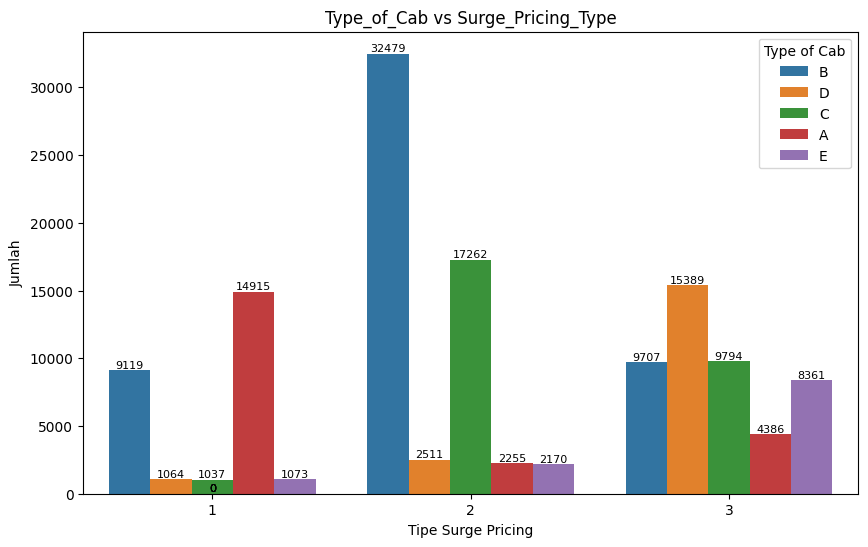

In [71]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='Surge_Pricing_Type', hue='Type_of_Cab')
plt.title('Type_of_Cab vs Surge_Pricing_Type')
plt.xlabel('Tipe Surge Pricing')
plt.ylabel('Jumlah')
plt.legend(title='Type of Cab')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.show()

4.7. Heatmap korelasi

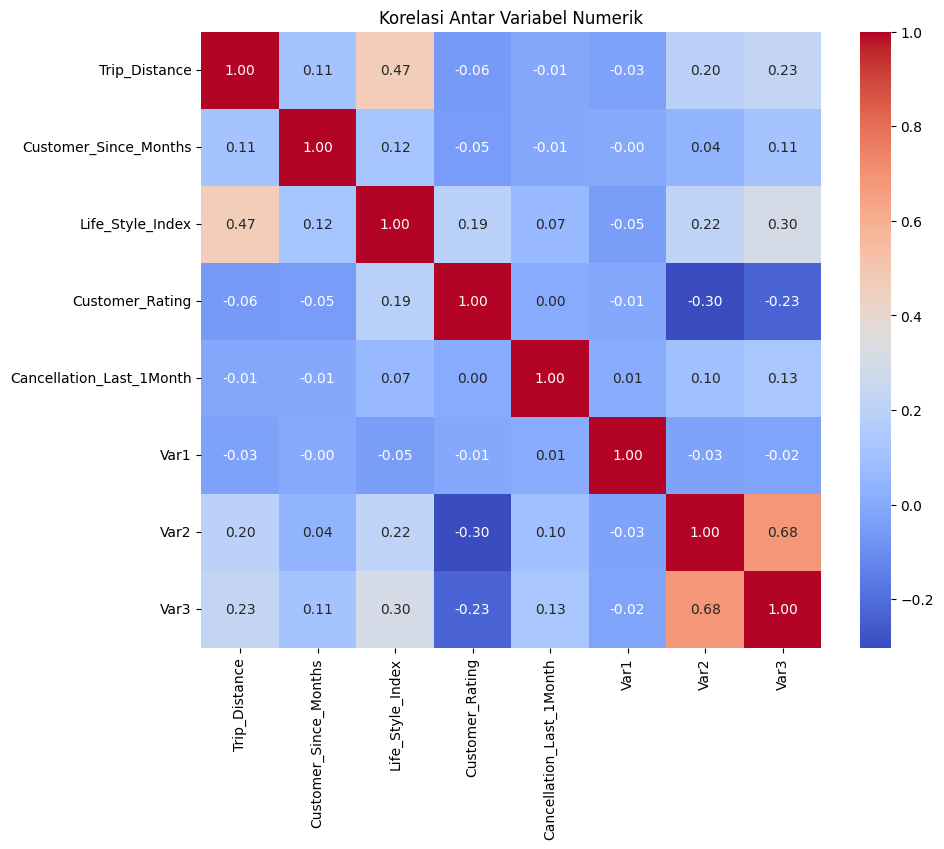

In [72]:
numerical_cols = ['Trip_Distance', 'Customer_Since_Months', 'Life_Style_Index',
                  'Customer_Rating', 'Cancellation_Last_1Month', 'Var1', 'Var2', 'Var3']

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

# **Langkah 5**: PowerBI

In [73]:
# Ekspor dataset final ke CSV
df.to_csv('sigma_cabs_clean.csv', index=False)

# Download ke lokal (otomatis)
from google.colab import files
files.download('sigma_cabs_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>